In [22]:
# ============================================================
# CELL 1 — SETUP & IMPORTS (with Metal / MPS support)
# ============================================================

import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ---------------------------
# Reproducibility
# ---------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ---------------------------
# DEVICE SELECTION
# ---------------------------

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    # Metal MPS support on macOS (Apple Silicon or AMD Metal enabled)
    device = torch.device("mps")
    print("Using Apple Metal Performance Shaders (MPS) GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

print("Selected device:", device)
print("PyTorch version:", torch.__version__)

Using Apple Metal Performance Shaders (MPS) GPU
Selected device: mps
PyTorch version: 2.10.0


In [23]:
# ============================================================
# CELL 2 — HYPERPARAMETERS & OUTPUT DIRECTORIES
# ============================================================

BATCH_SIZE = 128
EPOCHS = 20
LR = 1e-3
NUM_CLASSES = 10
NUM_WORKERS = 0

OUTPUT_DIR = "outputs_resnet_skip"
PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
MODELS_DIR = os.path.join(OUTPUT_DIR, "models")

os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("Batch:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("LR:", LR)

Batch: 128
Epochs: 20
LR: 0.001


In [24]:
# ============================================================
# CELL 3 — SVHN DATASET
# ============================================================

DATA_DIR = "./data_svhn"

mean = [0.4377, 0.4438, 0.4728]
std = [0.1980, 0.2010, 0.1970]

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = datasets.SVHN(root=DATA_DIR, split="train", download=True, transform=transform_train)
test_ds = datasets.SVHN(root=DATA_DIR, split="test", download=True, transform=transform_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

print("Train:", len(train_ds))
print("Test:", len(test_ds))

Train: 73257
Test: 26032


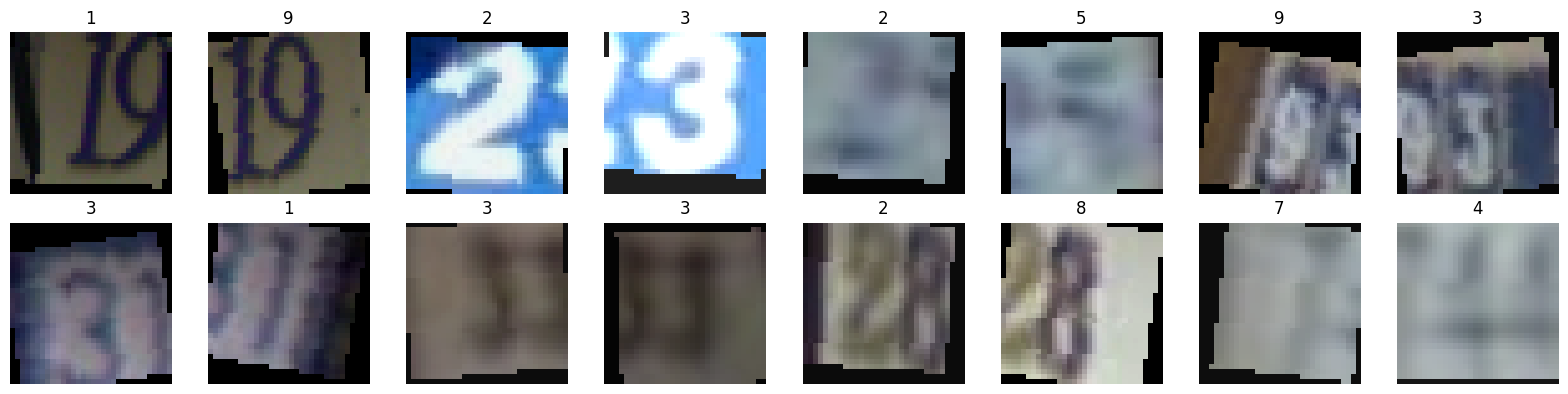

In [25]:
# ============================================================
# CELL 4 — VISUALIZE SAMPLES
# ============================================================

def visualize_samples(dataset):
    fig, axes = plt.subplots(2, 8, figsize=(16,4))
    mean_t = torch.tensor(mean).view(3,1,1)
    std_t = torch.tensor(std).view(3,1,1)

    for i, ax in enumerate(axes.flat):
        img, label = dataset[i]
        img = (img * std_t + mean_t).clamp(0,1)
        ax.imshow(img.permute(1,2,0).numpy())
        ax.set_title(str(label))
        ax.axis("off")

    plt.tight_layout()
    plt.show()

visualize_samples(train_ds)

In [26]:
# ============================================================
# CELL 5 — RESNET-20 (WITH SKIP CONNECTIONS)
# ============================================================

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)

        self.conv2 = nn.Conv2d(planes, planes, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, 1, stride, bias=False),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out += identity
        out = torch.relu(out)

        return out


class ResNet20(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.in_planes = 16

        self.conv1 = nn.Conv2d(3, 16, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)

        self.layer1 = self._make_layer(16, 3, stride=1)
        self.layer2 = self._make_layer(32, 3, stride=2)
        self.layer3 = self._make_layer(64, 3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(64, num_classes)

        self._init_weights()

    def _make_layer(self, planes, blocks, stride):
        strides = [stride] + [1]*(blocks-1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_planes, planes, s))
            self.in_planes = planes
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = torch.flatten(out,1)
        out = self.fc(out)
        return out


model = ResNet20(NUM_CLASSES).to(device)
print(model)

ResNet20(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affin

In [27]:
# ============================================================
# CELL 6 — GRADIENT TRACKING SETUP
# ============================================================

TRACKED_LAYERS = {
    "conv1": model.conv1,
    "layer1.0.conv1": model.layer1[0].conv1,
    "layer1.2.conv2": model.layer1[2].conv2,
    "layer2.0.conv1": model.layer2[0].conv1,
    "layer2.2.conv2": model.layer2[2].conv2,
    "layer3.0.conv1": model.layer3[0].conv1,
    "layer3.2.conv2": model.layer3[2].conv2,
}

history = {
    "train_loss": [], "train_acc": [],
    "test_loss": [], "test_acc": [],
    "epoch_grad_norms": {k: [] for k in TRACKED_LAYERS},
    "batch_grad_norms": {k: [] for k in TRACKED_LAYERS},
    "weight_norms": {name: [] for name in TRACKED_LAYERS},
    "weight_deltas": {name: [] for name in TRACKED_LAYERS},
}

# Store initial weights for computing weight deltas
prev_weights = {}
for name, layer in TRACKED_LAYERS.items():
    prev_weights[name] = layer.weight.data.clone()


In [28]:
# ============================================================
# CELL 7 — TRAINING FUNCTIONS
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

def train_one_epoch():
    global prev_weights
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    batch_store = defaultdict(list)

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # log gradients per batch
        for name, layer in TRACKED_LAYERS.items():
            if layer.weight.grad is not None:
                g = layer.weight.grad.norm(2).item()
                batch_store[name].append(g)

        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    # --- End-of-epoch tracking ---
    for name, layer in TRACKED_LAYERS.items():
        # Epoch gradient norms
        grads = batch_store[name]
        history["epoch_grad_norms"][name].append(np.mean(grads))
        history["batch_grad_norms"][name].extend(grads)

        # Weight norms
        w_norm = layer.weight.data.norm(2).item()
        history["weight_norms"][name].append(w_norm)

        # Weight deltas
        w_delta = (layer.weight.data - prev_weights[name]).norm(2).item()
        history["weight_deltas"][name].append(w_delta)

        # Update prev_weights for next epoch
        prev_weights[name] = layer.weight.data.clone()

    history["train_loss"].append(running_loss/len(train_loader))
    history["train_acc"].append(100*correct/total)

def evaluate():
    model.eval()
    running_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            preds = outputs.argmax(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    history["test_loss"].append(running_loss/len(test_loader))
    history["test_acc"].append(100*correct/total)

    return np.array(all_preds), np.array(all_labels)


In [29]:
# ============================================================
# CELL 8 — TRAINING LOOP
# ============================================================

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_one_epoch()
    all_preds, all_labels = evaluate()

    print("Train Acc:", history["train_acc"][-1])
    print("Test Acc:", history["test_acc"][-1])

# Save the trained model
torch.save(model.state_dict(), "resnet_with_skip.pth")
print("Model saved to resnet_with_skip.pth")



Epoch 1/20


100%|██████████| 573/573 [00:22<00:00, 25.92it/s]


Train Acc: 67.73823661902617
Test Acc: 87.82652120467118

Epoch 2/20


100%|██████████| 573/573 [00:22<00:00, 25.87it/s]


Train Acc: 88.6181525314987
Test Acc: 89.13644744929317

Epoch 3/20


...

Train Acc: 95.28645726688235
Test Acc: 94.94084204056546

Epoch 19/20


100%|██████████| 573/573 [00:22<00:00, 25.80it/s]


Train Acc: 95.30420301131632
Test Acc: 95.39028887523048

Epoch 20/20


100%|██████████| 573/573 [00:22<00:00, 26.01it/s]


Train Acc: 95.44616896678815
Test Acc: 95.62845728334358
Model saved to resnet_with_skip.pth


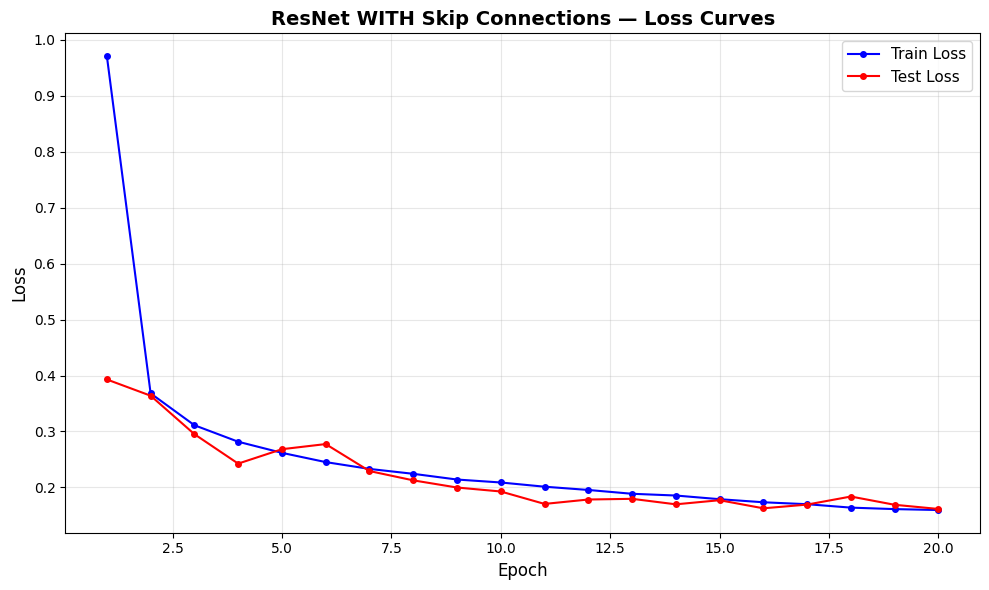

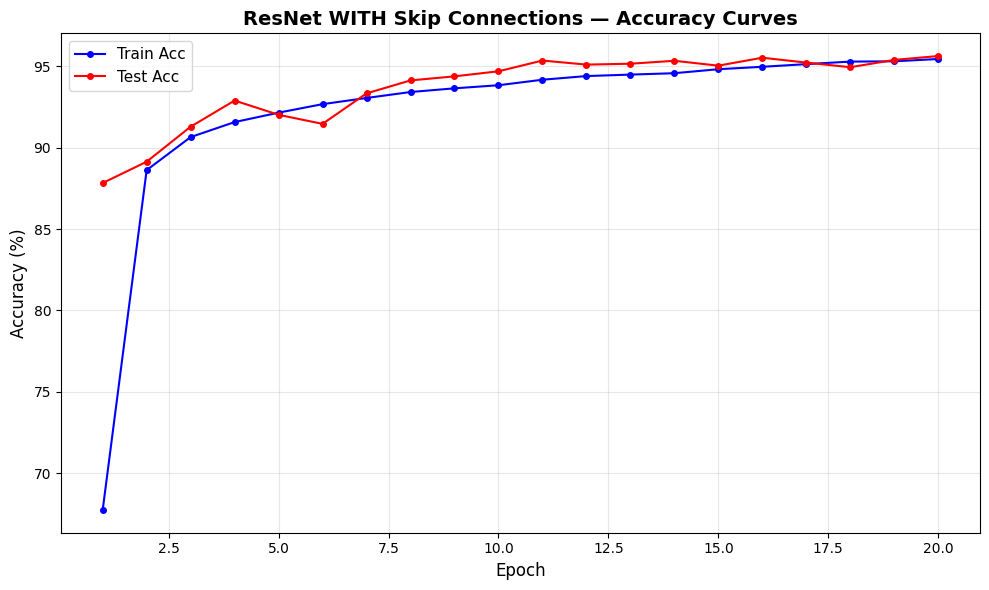

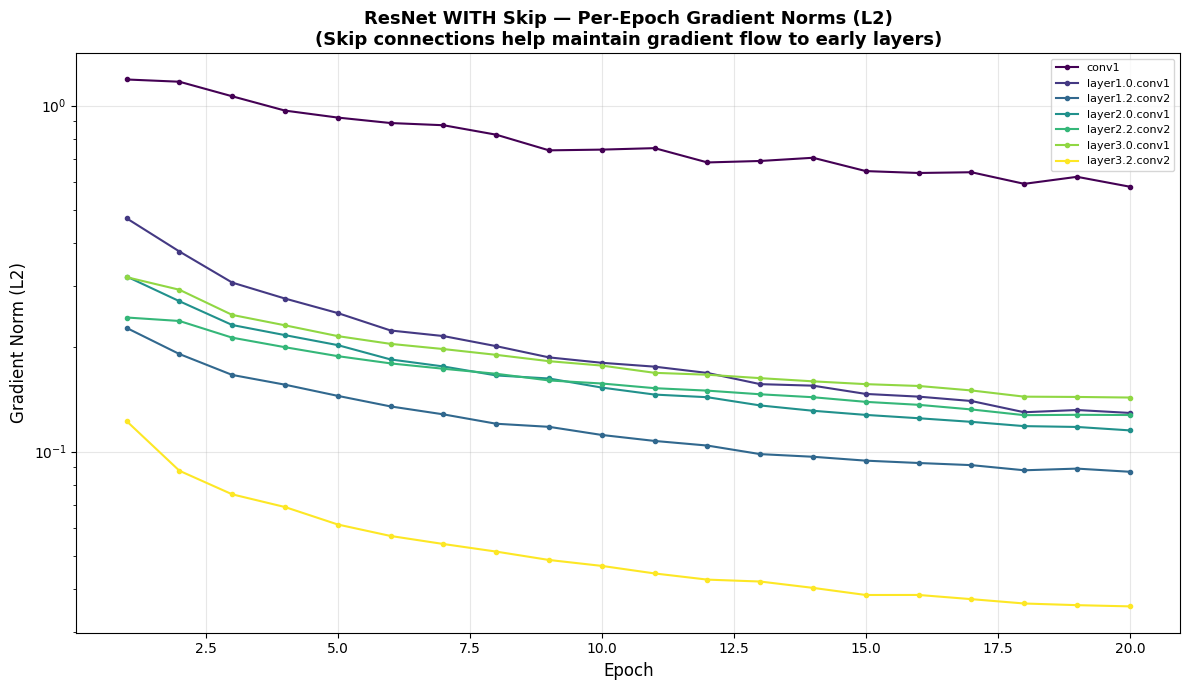

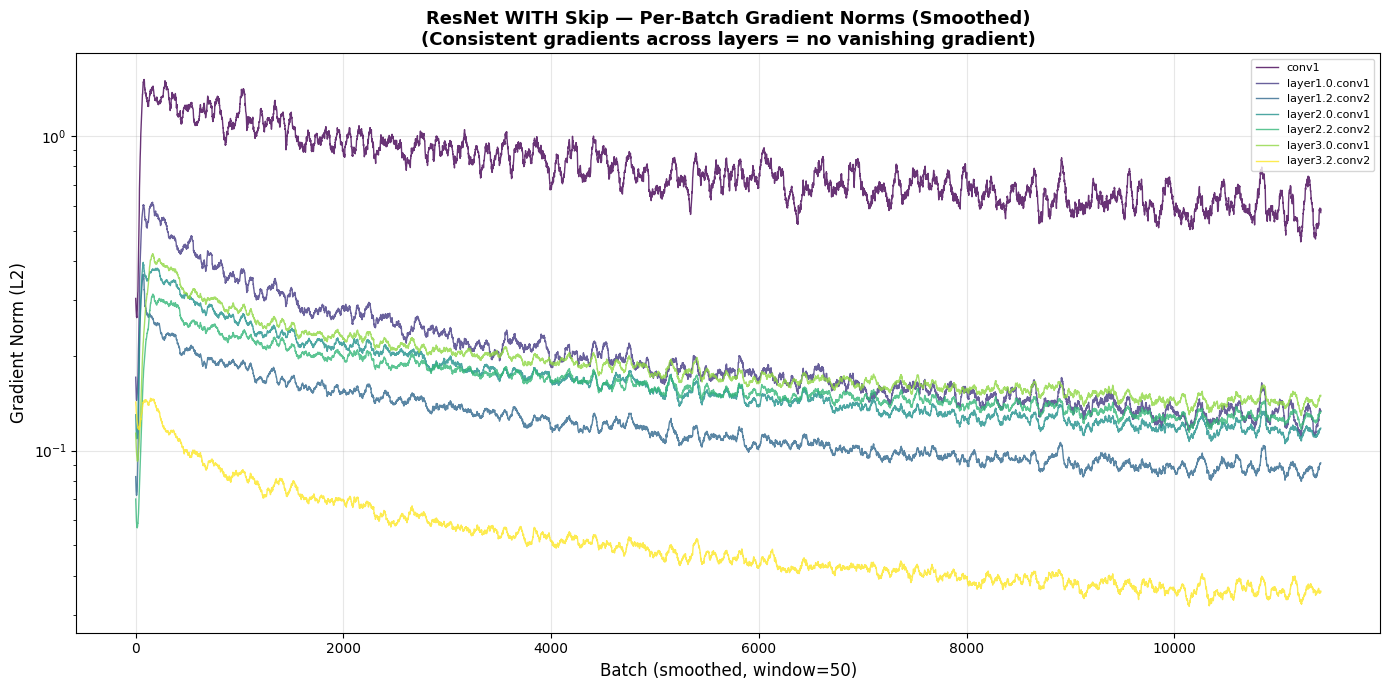

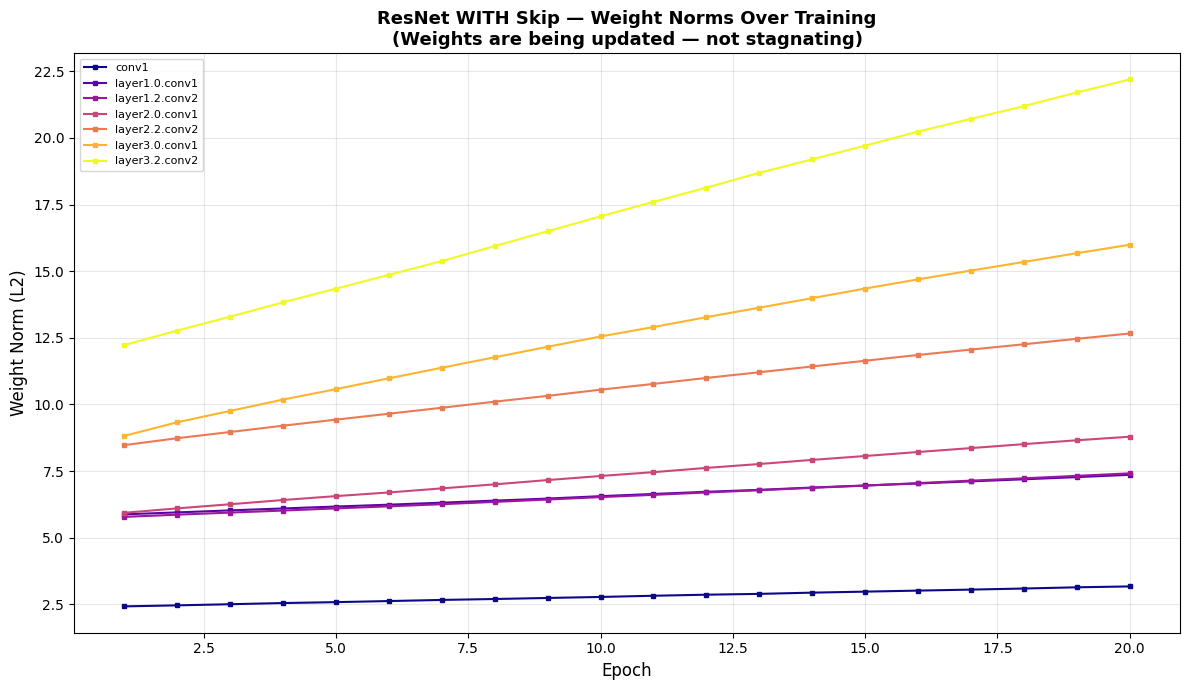

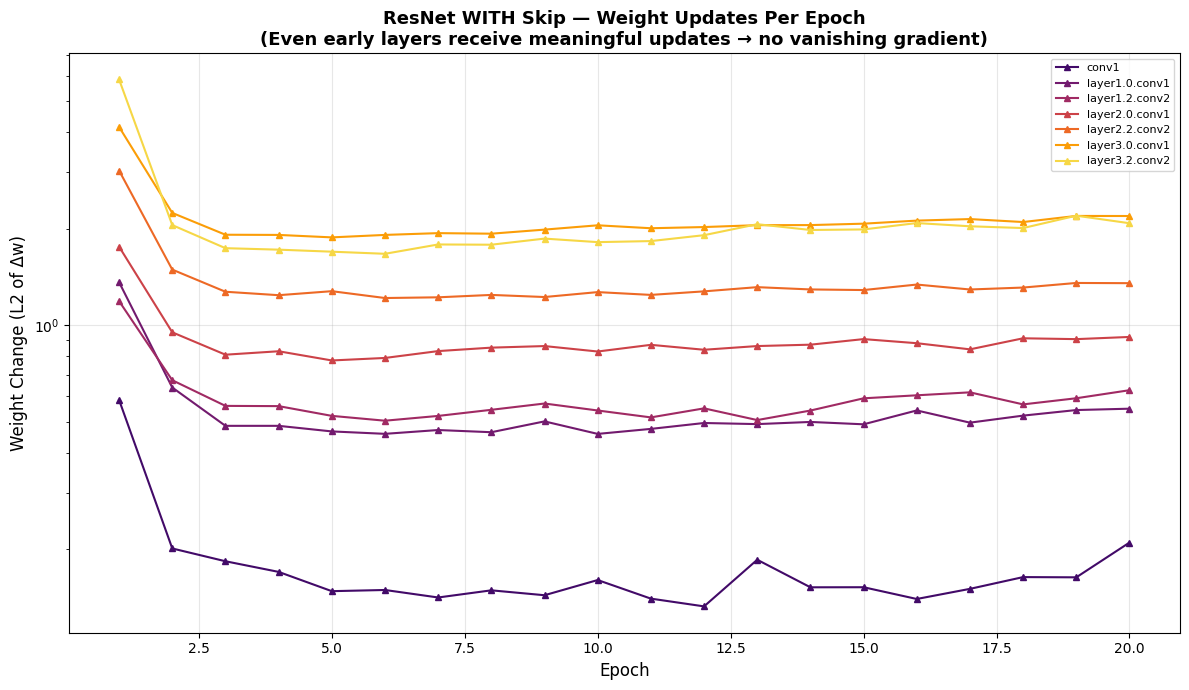

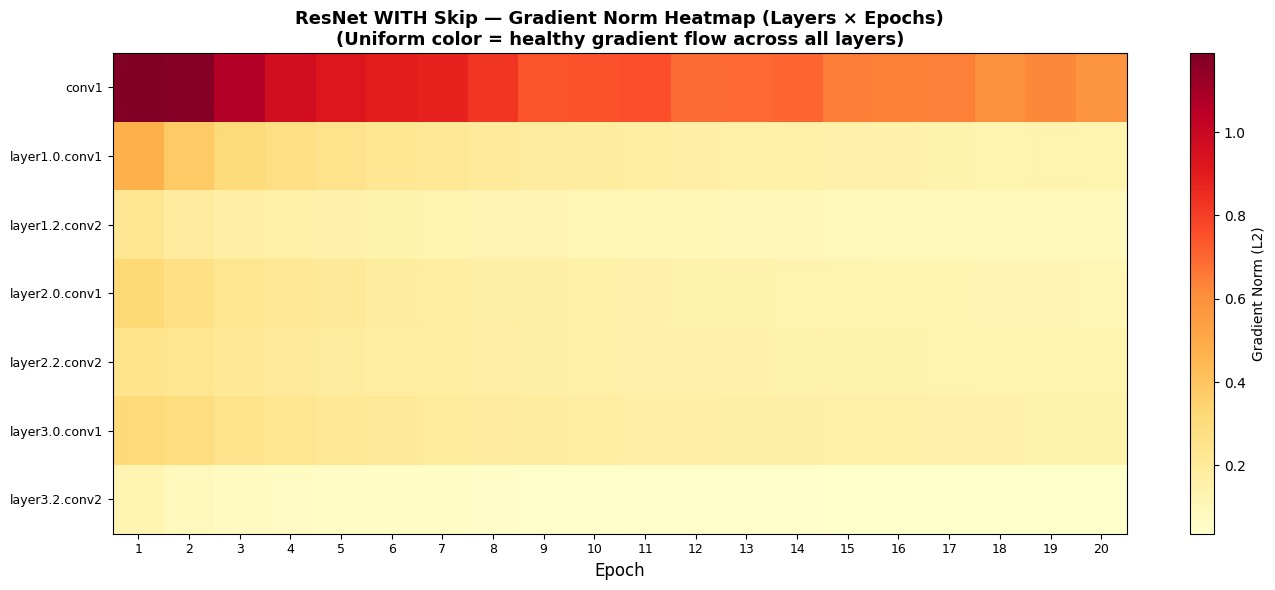

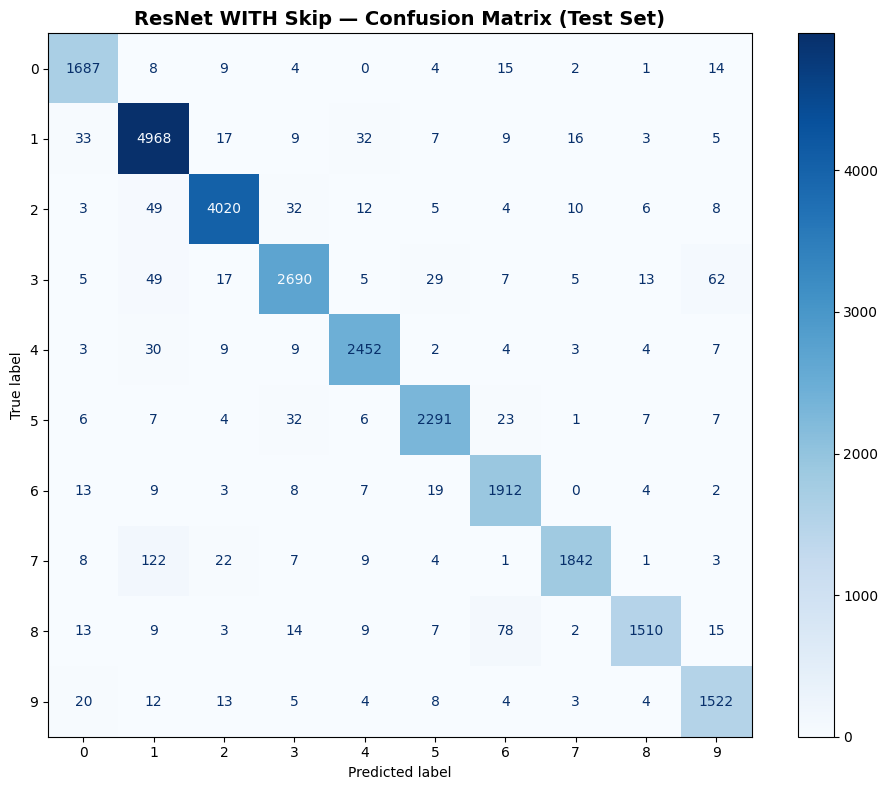

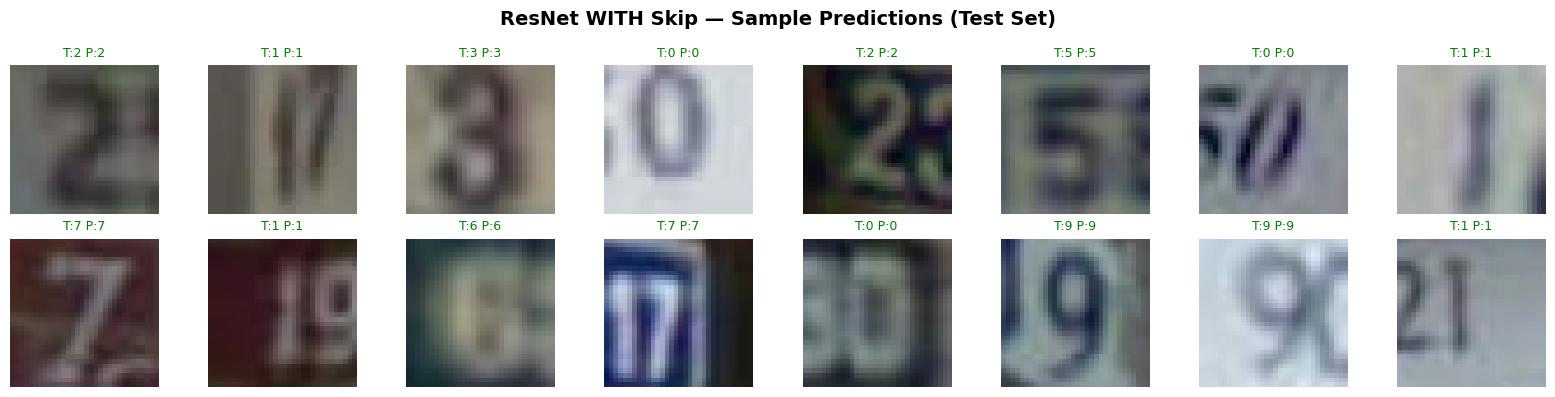

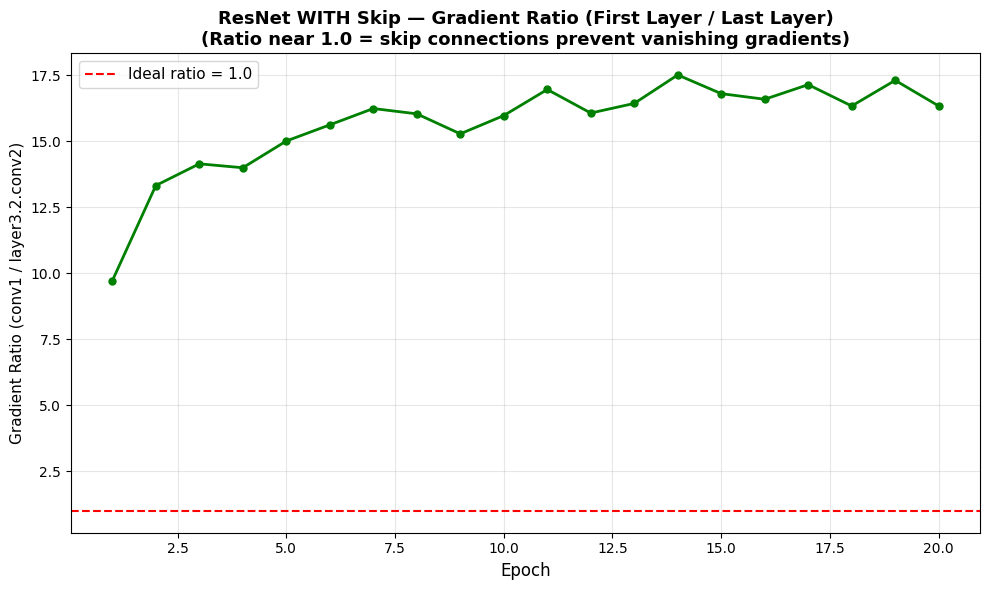

✅ All 10 plots displayed and saved successfully.


In [30]:
# ============================================================
# CELL 9 — PLOTS (DISPLAY + SAVE)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

epochs_range = range(1, EPOCHS+1)

# ------------------------------------------------------------
# 1️⃣ LOSS CURVE
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history["train_loss"], "b-o", label="Train Loss", markersize=4)
plt.plot(epochs_range, history["test_loss"], "r-o", label="Test Loss", markersize=4)
plt.title("ResNet WITH Skip Connections — Loss Curves", fontsize=14, fontweight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ------------------------------------------------------------
# 2️⃣ ACCURACY CURVE
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history["train_acc"], "b-o", label="Train Acc", markersize=4)
plt.plot(epochs_range, history["test_acc"], "r-o", label="Test Acc", markersize=4)
plt.title("ResNet WITH Skip Connections — Accuracy Curves", fontsize=14, fontweight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("accuracy_curves.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ------------------------------------------------------------
# 3️⃣ EPOCH GRADIENT NORMS
# ------------------------------------------------------------
plt.figure(figsize=(12, 7))
colors = plt.cm.viridis(np.linspace(0, 1, len(TRACKED_LAYERS)))
for (name, _), color in zip(TRACKED_LAYERS.items(), colors):
    plt.plot(epochs_range, history["epoch_grad_norms"][name],
             "-o", label=name, color=color, markersize=3)
plt.yscale("log")
plt.title("ResNet WITH Skip — Per-Epoch Gradient Norms (L2)\n"
          "(Skip connections help maintain gradient flow to early layers)",
          fontsize=13, fontweight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Gradient Norm (L2)", fontsize=12)
plt.legend(fontsize=8, loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("epoch_gradient_norms.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ------------------------------------------------------------
# 4️⃣ BATCH GRADIENT NORMS (Smoothed) — only if tracked
# ------------------------------------------------------------
if "batch_grad_norms" in history:
    plt.figure(figsize=(14, 7))
    colors = plt.cm.viridis(np.linspace(0, 1, len(TRACKED_LAYERS)))
    for (name, _), color in zip(TRACKED_LAYERS.items(), colors):
        norms = history["batch_grad_norms"][name]
        window = 50
        if len(norms) > window:
            smoothed = np.convolve(norms, np.ones(window)/window, mode="valid")
            plt.plot(smoothed, label=name, color=color, alpha=0.8, linewidth=1)
        else:
            plt.plot(norms, label=name, color=color, alpha=0.8, linewidth=1)
    plt.yscale("log")
    plt.title("ResNet WITH Skip — Per-Batch Gradient Norms (Smoothed)\n"
              "(Consistent gradients across layers = no vanishing gradient)",
              fontsize=13, fontweight="bold")
    plt.xlabel("Batch (smoothed, window=50)", fontsize=12)
    plt.ylabel("Gradient Norm (L2)", fontsize=12)
    plt.legend(fontsize=8, loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("batch_gradient_norms.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    print("⚠️ Skipping batch gradient norms plot (not tracked in training)")


# ------------------------------------------------------------
# 5️⃣ WEIGHT NORMS — only if tracked
# ------------------------------------------------------------
if "weight_norms" in history:
    plt.figure(figsize=(12, 7))
    colors = plt.cm.plasma(np.linspace(0, 1, len(TRACKED_LAYERS)))
    for (name, _), color in zip(TRACKED_LAYERS.items(), colors):
        plt.plot(epochs_range, history["weight_norms"][name],
                 "-s", label=name, color=color, markersize=3)
    plt.title("ResNet WITH Skip — Weight Norms Over Training\n"
              "(Weights are being updated — not stagnating)",
              fontsize=13, fontweight="bold")
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Weight Norm (L2)", fontsize=12)
    plt.legend(fontsize=8, loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("weight_norms.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    print("⚠️ Skipping weight norms plot (not tracked in training)")


# ------------------------------------------------------------
# 6️⃣ WEIGHT DELTAS — only if tracked
# ------------------------------------------------------------
if "weight_deltas" in history:
    plt.figure(figsize=(12, 7))
    colors = plt.cm.inferno(np.linspace(0.2, 0.9, len(TRACKED_LAYERS)))
    for (name, _), color in zip(TRACKED_LAYERS.items(), colors):
        plt.plot(epochs_range, history["weight_deltas"][name],
                 "-^", label=name, color=color, markersize=4)
    plt.yscale("log")
    plt.title("ResNet WITH Skip — Weight Updates Per Epoch\n"
              "(Even early layers receive meaningful updates → no vanishing gradient)",
              fontsize=13, fontweight="bold")
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Weight Change (L2 of Δw)", fontsize=12)
    plt.legend(fontsize=8, loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("weight_deltas.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    print("⚠️ Skipping weight deltas plot (not tracked in training)")



# ------------------------------------------------------------
# 7️⃣ GRADIENT HEATMAP (Layers × Epochs)
# ------------------------------------------------------------
layer_names = list(TRACKED_LAYERS.keys())
data = np.array([history["epoch_grad_norms"][name] for name in layer_names])

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(data, aspect="auto", cmap="YlOrRd", interpolation="nearest")
ax.set_yticks(range(len(layer_names)))
ax.set_yticklabels(layer_names, fontsize=9)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_xticks(range(EPOCHS))
ax.set_xticklabels(range(1, EPOCHS + 1), fontsize=9)
ax.set_title("ResNet WITH Skip — Gradient Norm Heatmap (Layers × Epochs)\n"
             "(Uniform color = healthy gradient flow across all layers)",
             fontsize=13, fontweight="bold")
plt.colorbar(im, ax=ax, label="Gradient Norm (L2)")
plt.tight_layout()
plt.savefig("gradient_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ------------------------------------------------------------
# 8️⃣ CONFUSION MATRIX
# ------------------------------------------------------------
# Collect predictions if not already available
if all_preds is None or all_labels is None:
    model.eval()
    all_preds_list = []
    all_labels_list = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            all_preds_list.extend(predicted.cpu().numpy())
            all_labels_list.extend(labels.cpu().numpy())
    all_preds = np.array(all_preds_list)
    all_labels = np.array(all_labels_list)

num_classes = len(set(all_labels))
cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[str(i) for i in range(num_classes)])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("ResNet WITH Skip — Confusion Matrix (Test Set)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ------------------------------------------------------------
# 9️⃣ SAMPLE PREDICTIONS
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle("ResNet WITH Skip — Sample Predictions (Test Set)",
             fontsize=14, fontweight="bold")

mean = torch.tensor([0.4377, 0.4438, 0.4728]).view(3, 1, 1)
std  = torch.tensor([0.1980, 0.2010, 0.1970]).view(3, 1, 1)

indices = np.random.choice(len(test_ds), 16, replace=False)
for i, ax in enumerate(axes.flat):
    idx = indices[i]
    img, true_label = test_ds[idx]
    img_display = img * std + mean
    img_display = img_display.clamp(0, 1)
    pred_label = all_preds[idx]
    color = "green" if pred_label == true_label else "red"
    ax.imshow(img_display.permute(1, 2, 0).numpy())
    ax.set_title(f"T:{true_label} P:{pred_label}", fontsize=9, color=color)
    ax.axis("off")

plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ------------------------------------------------------------
# 🔟 GRADIENT RATIO (First Layer / Last Layer)
# ------------------------------------------------------------
layer_names = list(TRACKED_LAYERS.keys())
first_layer = layer_names[0]
last_layer  = layer_names[-1]

first_grads = np.array(history["epoch_grad_norms"][first_layer])
last_grads  = np.array(history["epoch_grad_norms"][last_layer])
ratio = first_grads / (last_grads + 1e-10)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, ratio, "g-o", markersize=5, linewidth=2)
plt.axhline(y=1.0, color="red", linestyle="--", label="Ideal ratio = 1.0")
plt.title("ResNet WITH Skip — Gradient Ratio (First Layer / Last Layer)\n"
          "(Ratio near 1.0 = skip connections prevent vanishing gradients)",
          fontsize=13, fontweight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel(f"Gradient Ratio ({first_layer} / {last_layer})", fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("gradient_ratio.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


print("✅ All 10 plots displayed and saved successfully.")


In [31]:
# ============================================================
# FINAL SAVE CELL — Plots + Model + Training History
# ============================================================

import torch
import json
import os

SAVE_DIR = "/content/svhn_resnet_results"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1️⃣ Save Model Weights
# ------------------------------------------------------------
MODEL_PATH = os.path.join(SAVE_DIR, "resnet20_svhn_with_skip.pth")

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "history": history,
    "num_classes": NUM_CLASSES,
}, MODEL_PATH)

print(f"Model saved at: {MODEL_PATH}")

# ------------------------------------------------------------
# 2️⃣ Save Training History as JSON
# ------------------------------------------------------------
HISTORY_PATH = os.path.join(SAVE_DIR, "training_history.json")

with open(HISTORY_PATH, "w") as f:
    json.dump(history, f)

print(f"History saved at: {HISTORY_PATH}")

# ------------------------------------------------------------
# 3️⃣ Zip Everything (Optional for download)
# ------------------------------------------------------------
import shutil

ZIP_PATH = "/content/svhn_resnet_results.zip"
shutil.make_archive("/content/svhn_resnet_results", 'zip', SAVE_DIR)

print(f"All results zipped at: {ZIP_PATH}")

OSError: [Errno 30] Read-only file system: '/content'

In [ ]:
# ============================================================
# FINAL SAVE EVERYTHING CELL
# ============================================================

import os
import shutil
import torch
import json

SAVE_DIR = "/content/svhn_resnet_submission"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1️⃣ List of All Plot Files
# ------------------------------------------------------------
plot_files = [
    "accuracy_curves.png",
    "batch_gradient_norms.png",
    "confusion_matrix.png",
    "epoch_gradient_norms.png",
    "gradient_heatmap.png",
    "gradient_ratio.png",
    "loss_curves.png",
    "sample_images.png",
    "sample_predictions.png",
    "weight_deltas.png",
    "weight_norms.png",
]

# ------------------------------------------------------------
# 2️⃣ Copy All Plots to Submission Folder
# ------------------------------------------------------------
for file in plot_files:
    if os.path.exists(file):
        shutil.copy(file, os.path.join(SAVE_DIR, file))
    else:
        print(f"Warning: {file} not found")

print("All plots copied.")

# ------------------------------------------------------------
# 3️⃣ Save Model Checkpoint
# ------------------------------------------------------------
model_path = os.path.join(SAVE_DIR, "resnet20_svhn_with_skip.pth")

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "history": history,
    "num_classes": NUM_CLASSES,
}, model_path)

print("Model saved.")

# ------------------------------------------------------------
# 4️⃣ Save History Separately (Optional)
# ------------------------------------------------------------
history_path = os.path.join(SAVE_DIR, "training_history.json")

with open(history_path, "w") as f:
    json.dump(history, f)

print("History saved.")

# ------------------------------------------------------------
# 5️⃣ Zip Everything
# ------------------------------------------------------------
zip_path = "/content/svhn_resnet_submission.zip"
shutil.make_archive("/content/svhn_resnet_submission", 'zip', SAVE_DIR)

print("\nEverything saved and zipped!")
print(f"Download: {zip_path}")

OSError: [Errno 30] Read-only file system: '/content'